In [91]:
import numpy as np
import matplotlib.pyplot as plt 

Introduction:

The project focuses on analyzing the U.S quarterly real GDP growth rates from 2010 to 2023, using seasonally adjusted annual rate data from the U.S Bureau of Economic Analysis. The dataset includes significat economic fluctuations due to including the data from the Covid pandemic. In this project, I implemented 3 custom numerical methods:

Least squares Linear Regression, which finds the best-fit straight line to approximate the overall trend and minimize the errors. 

Polynomial fitting, which uses a single, higher-degree curve to approximate all of the data.

Cubic Splines, which connect every data point exactly using smooth, piecewise cubic functions.

Part A — Cubic Spline Interpolation

1.

In [92]:
#Creating the initial array's which will store the data
# x => quarter indicies, y => real GDP growth rates (%)

x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

In [93]:
#custom cubic spline fitting
n = len(x)
h = np.zeros(n-1)


#calculating the step sizes between data points
for i in range(n-1):
    h[i] = x[i+1] - x[i]

#initializing arrays for the tridiagonal system (A,B,C => matrix, D => RHS)
A = np.zeros(n-2)
B = np.zeros(n-2)
C = np.zeros(n-2)
D = np.zeros(n-2)

#populating the tridiagonal mtrix, based on C0, C1, C2 continuity conditions at interior knots
for i in range(1, n-1):
    A[i-1] = h[i-1]
    B[i-1] = 2 * (h[i-1] + h[i])
    C[i-1] = h[i]
    D[i-1] = 6 * (((y[i+1] - y[i]) / h[i]) - ((y[i] - y[i-1]) / h[i-1]))




def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    
    Returns: solution vector x of length n
    """
    n = len(b)
    
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]

    return x


inter_M = thomas_algorithm(A,B,C,D)


M = np.zeros(n)
# This places the internal M values into the array, leaving M[0] and M[-1] as 0
M[1:-1] = inter_M


def evaluate_spline(x_eval):
    #the function evaluates the cubic spline at any given point
    n = len(x)
    
    
    for i in range(n-1):
        if (x[i] <= x_eval <= x[i + 1]):
            break
            
    dx = x_eval - x[i]
    
    #compute coefficients for the cubic polynomial
    a = y[i]
    b = (y[i+1] - y[i]) / h[i] - h[i] * (2 * M[i] + M[i+1]) / 6
    c = M[i] / 2
    d = (M[i+1] - M[i]) / (6 * h[i])
    
    y_eval = a + b * dx + c * dx**2 + d * dx**3
    
    
    return y_eval

In [94]:
#first interior knot (x = 5)
x_val = 5
step = 0.0001

#C0 continuity
y_left = evaluate_spline(x_val - step)
y_right = evaluate_spline(x_val + step)

print("C0 Continuity")
print("Left side:", y_left)
print("Right side:", y_right)
print()

#first derivative continutity
first_derivative_left = (evaluate_spline(x_val) - evaluate_spline(x_val - step)) / step
first_derivative_right = (evaluate_spline(x_val + step) - evaluate_spline(x_val)) / step

print("First Derivative")
print("Left side:", first_derivative_left)
print("Right side:", first_derivative_right)
print()

# 2nd derivative continutity
sec_derivative_left = (evaluate_spline(x_val) - 2 * evaluate_spline(x_val - step) + evaluate_spline(x_val - 2 * step)) / (step**2)
sec_derivative_right = (evaluate_spline(x_val + 2 * step) - 2 * evaluate_spline(x_val + step) + evaluate_spline(x_val)) / (step**2)

print("2nd Derivative")
print("Left side:", sec_derivative_left)
print("Right side:", sec_derivative_right)

C0 Continuity
Left side: 0.09998732299332058
Right side: 0.10001268095756373

First Derivative
Left side: 0.12677006679506775
Right side: 0.12680957563640516

2nd Derivative
Left side: 0.3950824778442552
Right side: 0.395078623982581


Continuity at the interior knots has been verified.

Clearly describe the system of equations you solve: how many unknowns are there, what are the continuity conditions at each interior knot, and what boundary conditions define a natural spline?

To figure out the natural cubic spline, a tridiagonal system of linear equations is contructed above, in order to find the second derivatives at the interior points. There are 18 unknowns (n-2) in this  system of equations, as the second derivatives at the ends are zero. At each interiror knot, the continuity conditions require that the cubic polynomials have the same value and first ,and second derivatives. The boundary conditions simply state that the second derivatives at the first and last datapoints are zero.

2.

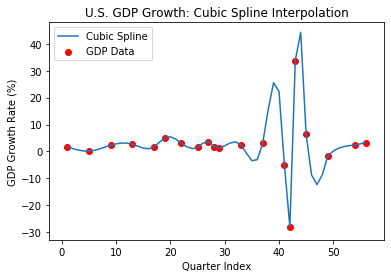

In [95]:
#array of x values for a smooth curve
x_plot = np.arange(1,57)
y_plot = []

#evaluating the spline at each point
for num in x_plot:
    y_calc = evaluate_spline(num)
    y_plot.append(y_calc)

    
#plotting the interpolated cubic spline against the original GDP data
plt.plot(x_plot, y_plot, label='Cubic Spline')
plt.scatter(x, y, color='red', label='GDP Data')
plt.title('U.S. GDP Growth: Cubic Spline Interpolation')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth Rate (%)')
plt.legend()
plt.show()

Discuss whether the interpolant is visually smooth and reasonable:

The interpolant is visually smooth, as the function and it's first two derivatives are continious at every point. It is not particularly reasonable due to very wild oscillations, which occur due to hitting the outlier points. The curve stays smooth, but is likely inaccurate.

3.

Due to the fact that my cubic spline interpolation is forced to perfectly interpolate the COVID outliers, it creates severe localized overshoot rather than the Runge phenomenon. Because my interpolation is forced to hit the outliers, which do not represent the usual trend, the curve’s predictive value significantly goes down in the surrounding quarters, showing a trade-off between exact interpolation and numerical stability. Weighted least squares would be preferable, as it helps identify the data points which are anomalies, and therefore would be able to provide a much better fit, while smoothing splines would relax the requirement to pass through every point and reduce the overshoot.

Part B — Polynomial & Least Squares Comparison
Fit a degree-4 polynomial to the data using least squares (this does not need to pass
through every point). Plot it alongside the cubic spline. Which model better captures the
overall trend, and which better reproduces specific data points? Discuss the trade-off
between approximation and interpolation.

1.

In [96]:
def cus_least_squares_4(x,y):
    n = len(x)
    
    #constructing the Vandermonde matrix
    A = np.column_stack([x**0, x**1, x**2, x**3, x**4])
    
    #condition number of the Vandermonde matrix
    print(f"Condition Number: {np.linalg.cond(A):.2e}")
    
    #setting up and solving the normal equations => (A^T * A) * coeffs = A^T * y
    LHS = A.T @ A
    RHS = A.T @ y
    coeffs = np.linalg.solve(LHS, RHS)
    
    return coeffs

In [97]:
x_lin = np.arange(1,56)

#automatically prints the condition #
a = cus_least_squares_4(x, y)

Condition Number: 1.82e+07


Condition number checked: (1.82e+07), which is safely below the 10^12 threshold.

In [98]:
# needed to plot a smooth curve
y_p = a[0] + a[1]*x_lin + a[2]*x_lin**2 + a[3]*x_lin**3 + a[4]*x_lin**4

# calculating RMSE (using actual data points 'x')
y_pred_points = a[0] + a[1]*x + a[2]*x**2 + a[3]*x**3 + a[4]*x**4
rmse = np.sqrt(np.mean((y - y_pred_points)**2))

print(f"Degree-4 Polynomial RMSE: {rmse:.4f}")

Degree-4 Polynomial RMSE: 10.0314


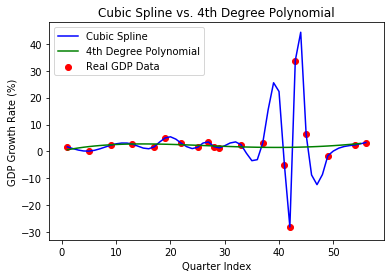

In [99]:
plt.plot(x_plot, y_plot, color='blue', label='Cubic Spline')
plt.plot(x_lin, y_p, color='green', label='4th Degree Polynomial')
plt.scatter(x, y, color='red', label='Real GDP Data')
plt.title('Cubic Spline vs. 4th Degree Polynomial')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth Rate (%)')
plt.legend()
plt.show()

The degree 4 polynomial does a better job at capturing the overall trend of the data, while the cubic spline does a much better job at hitting each point. This is a good demo of the trade-off between interpolation and approximation. Approximation in the form of the degree 4 polynomial better identifies the general pattern (despite having an RMSE of 10.0314), while interpolation leads to accuracy in the form of hitting each data point perfectly (resulting in an RMSE of 0).

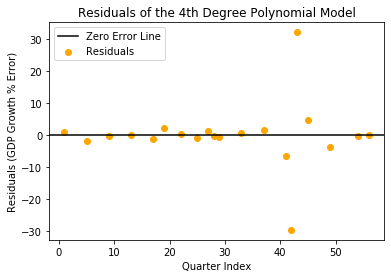

In [100]:
#predicted y at the original x

#residuals (Actual y - Predicted y)
y_pred_points = a[0] + a[1]*x + a[2]*x**2 + a[3]*x**3 + a[4]*x**4
residuals_poly = y - y_pred_points

#plotting
plt.scatter(x, residuals_poly, color='orange', label='Residuals')
plt.axhline(y=0, color='black', label='Zero Error Line')
plt.title('Residuals of the 4th Degree Polynomial Model')
plt.xlabel('Quarter Index')
plt.ylabel('Residuals (GDP Growth % Error)')
plt.legend()
plt.show()

2.

In [101]:
#custom linear least squares

def least_squares(x,y): 
    n = len(x)
    
    #computing the needed summation terms
    sum_x = x.sum()
    sum_y = y.sum()
    sum_xx = (x**2).sum()
    sum_xy = (x * y).sum()
    
    #calculating the slope and the y intercept
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_xx - sum_x**2)
    b = (sum_y - m * sum_x) / n
    
    return m, b

In [102]:
#using a mask to filter out covid
no_covid = (x < 41) | (x > 45)
x_f = x[no_covid]
y_f = y[no_covid]

In [103]:
m, b = least_squares(x_f, y_f)
print(f"The slope of the linear model is: {m:.4f}")
y_line = m * x_f + b

The slope of the linear model is: -0.0019


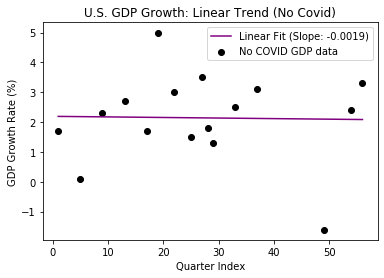

In [104]:
#plotting
plt.scatter(x_f, y_f, color='black', label='No COVID GDP data')
plt.plot(x_f, y_line, color='purple', label=f'Linear Fit (Slope: {m:.4f})')
plt.title('U.S. GDP Growth: Linear Trend (No Covid)')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth Rate (%)')
plt.legend()
plt.show()

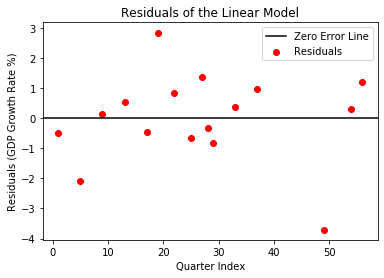

In [105]:
#residuals
residuals = y_f - y_line
plt.scatter(x_f, residuals, color='red', label='Residuals')
plt.axhline(y=0, color='black', label='Zero Error Line')
plt.title('Residuals of the Linear Model')
plt.xlabel('Quarter Index')
plt.ylabel('Residuals (GDP Growth Rate %)')
plt.legend()
plt.show()

Removing COVID outliers helps with a more stable approximatuion, but a linear trend does not make any sense nonetheless. The slope is -0.0019. It completely fails to capture the natural, cyclical fluctions of real GDP growth. Fitting a linear model like this requires the assumption that economic growth changes at a constant rate, which goes against the basic concepts of economics, such as business cycles.

Part C — Method Justification

1. For a policymaker who needs to estimate GDP growth for a quarter between two known data points (interpolation), which method would you recommend: cubic spline or polynomialfitting? Justify your answer with reference to smoothness, accuracy, and sensitivity to outliers.


If a policymaker was estimating GDP growth between known quarters, I would probably recommmend them to use cubic spline interpolation because it ensures perfect accuracy at the existing data points yielding an RMSE of 0.0000 while the 4th-degree polynomial is an approximation with a higher RMSE of 10.0314 while providing a smooth curve. Nonetheless, it is important to consider that splines are very sensitive to outlier data points, as could be seen through the implementation earlier, with the data including the COVID-19 shock, which caused innacurate oscialltions which are often mistaken for the Runge phenomenon. That phenomenon technically applies to high-degree global polynomials and these wiggles are actually a form of mathematical overshoot caused by the requirement to maintain smoothness while hitting extreme outliers. If the estimation is done somewhere near anomalies as such, it much safer and more reasonable to use a low-degree polynomial approximation, which would a safer alternative to capture the broad trend, not being highly sensitive to outliers.

Part C addendum:

Please include an analysis of the Big O for the different algorithms and ask if it changes
your recommendation. Please do a brief write up of what the Big O notation is and the
justification of your decision.


Condition Number: 1.90e+08
Condition Number: 1.90e+08
Condition Number: 1.90e+08
Condition Number: 1.90e+08
Condition Number: 1.90e+08


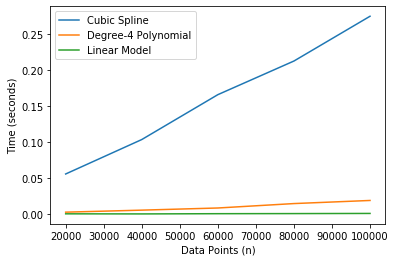

In [106]:
#doing the Big O tests for all the algorithms
import time

sizes = [20000, 40000, 60000, 80000, 100000]
spline_times = []
poly_times = []
linear_times = []

for n in sizes:
    # generating dummy data
    x_test = np.linspace(1, 100, n)
    y_test = np.random.rand(n)
    
    # timing the cubic spline
    start = time.time()
    h_test = np.diff(x_test)
    A_test = h_test[:-1]
    B_test = 2 * (h_test[:-1] + h_test[1:])
    C_test = h_test[1:]
    D_test = 6 * (((y_test[2:] - y_test[1:-1]) / h_test[1:]) - ((y_test[1:-1] - y_test[:-2]) / h_test[:-1]))
    
    thomas_algorithm(A_test, B_test, C_test, D_test)
    spline_times.append(time.time() - start)
    
    # timing the 4th degree polynomial
    start = time.time()
    cus_least_squares_4(x_test, y_test)
    poly_times.append(time.time() - start)
    
    # timing linear least squares
    start = time.time()
    least_squares(x_test, y_test)
    linear_times.append(time.time() - start)

# plotting
plt.plot(sizes, spline_times, label='Cubic Spline')
plt.plot(sizes, poly_times, label='Degree-4 Polynomial')
plt.plot(sizes, linear_times, label='Linear Model')
plt.xlabel('Data Points (n)')
plt.ylabel('Time (seconds)')
plt.legend()
plt.show()

Big O measueres an algorithm's worst case execution time as the dataset grows. The O(n) complexity for all three algorithms is demonstrated by the execution time graph above, which shows the lines for all three algorithms scaling linearly. Due to all 3 methods having pretty much the same efficiency, execution speed does not really make a difference. The original recommendation remains unchanged.

Conclusion:

Cubic spline interpolation performed best for exact estimation, but is very limited in it's sensitivity to outliers, which causes innacurate oscillations. The least squares polynomial fitting worked very well for trend analysis as it safely approximated the broad pattern, not overreacting to the pandemic shocks. Simpler linear models though, significantly oversimplify the cyclical behaviours of the economy. Overall, I learned that approxiamtion is safest for observing general trends, while interpolation should be used on more stable data.